# 002 — WTI Crude Oil Price

**Source:** FRED series `DCOILWTICO` via `fredapi`  
**File:** `data/raw/wti_daily.csv`  
**Units:** USD per barrel  
**Frequency:** Daily (business days); weekends/holidays interpolated  
**Coverage:** 2000-01-01 to present

**Goal:** Understand WTI crude price history in isolation — distribution, volatility regimes, key market events — and establish the context for its role as a gas model feature (associated gas / supply-side signal).

In [1]:
from pathlib import Path

# Auto-detect repository root from current working directory.
project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "data" / "raw").exists() and (parent / "notebooks").exists():
            project_root = parent
            break

print("Project root:", project_root)

Project root: C:\Users\alexd\Desktop\GIC\Prep\NatGasModel_US


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context="paper", font_scale=2.0, style="whitegrid")

DIAG = project_root / "diagram" / "data_overview" / "002_wti_crude_prices"
DIAG.mkdir(parents=True, exist_ok=True)

## 1. Load & Inspect

In [79]:
df = pd.read_csv(project_root / "data" / "raw" / "wti_daily.csv", index_col="date", parse_dates=True)
wti = df["wti_price"].astype(float)

full_idx = pd.date_range(start=wti.index.min(), end=wti.index.max(), freq="D")
wti = wti.reindex(full_idx).interpolate(method="time")
wti.index.name = "date"

print(f"Date range:   {wti.index.min().date()} → {wti.index.max().date()}")
print(f"Observations: {len(wti):,}")
print(f"Missing:      {wti.isna().sum()}")

Date range:   2000-01-03 → 2026-03-23
Observations: 9,577
Missing:      1


In [80]:
wti.to_frame().sample(5).sort_index()

,wti_price
date,
2001-09-21,25.460000
2003-02-02,33.063333
2004-02-10,34.030000
2020-01-20,58.325000
2020-11-18,41.640000


In [81]:
wti.describe().round(2)

count    9576.00
mean       63.81
std        24.92
min       -36.98
25%        45.11
50%        63.05
75%        81.47
max       145.31
Name: wti_price, dtype: float64

## 2. Full Price History

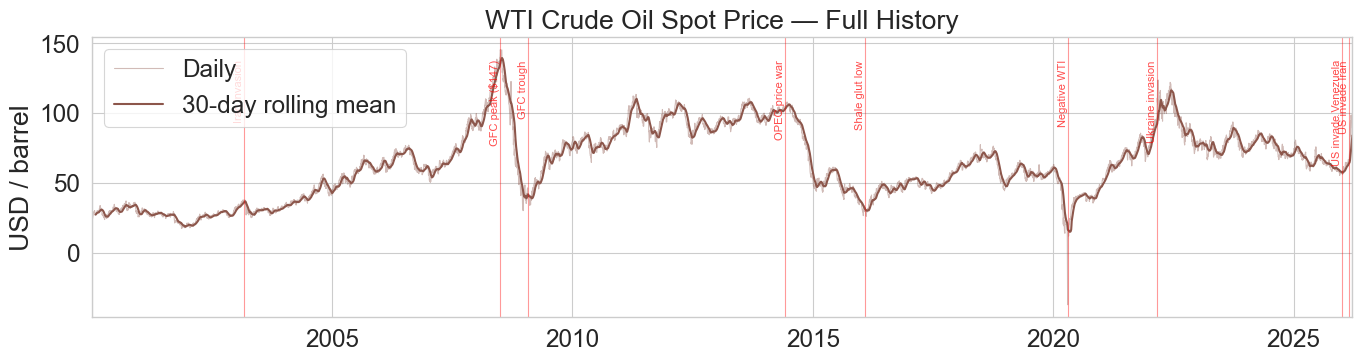

In [82]:
fig, ax = plt.subplots(figsize=(14, 4))

wti.plot(ax=ax, color="tab:brown", alpha=0.4, linewidth=0.8, label="Daily")
wti.rolling(30).mean().plot(ax=ax, color="tab:brown", linewidth=1.5, label="30-day rolling mean")

events = {
    "2003-03-01": "Iraq invasion",
    "2008-07-01": "GFC peak ($147)",
    "2009-02-01": "GFC trough",
    "2014-06-01": "OPEC price war",
    "2016-02-01": "Shale glut low",
    "2020-04-20": "Negative WTI",
    "2022-03-01": "Ukraine invasion",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), wti.max() * 0.95),
        fontsize=8,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("WTI Crude Oil Spot Price — Full History")
ax.set_ylabel("USD / barrel")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "wti_full_history.svg", format="svg", bbox_inches="tight")
plt.show()

## 3. Recent Period — 2020 to Present

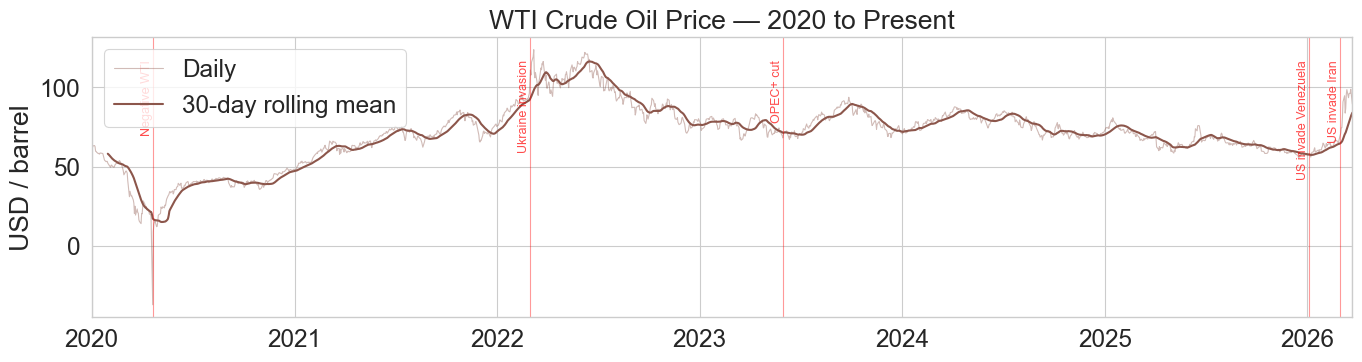

In [83]:
recent = wti["2020":]

fig, ax = plt.subplots(figsize=(14, 4))

recent.plot(ax=ax, color="tab:brown", alpha=0.4, linewidth=0.8, label="Daily")
recent.rolling(30).mean().plot(ax=ax, color="tab:brown", linewidth=1.5, label="30-day rolling mean")
#rolling(30) is a common technique to smooth out short-term fluctuations and highlight longer-term trends in time series data. It calculates the average of the data points within a specified window (in this case, 30 days) as it moves through the dataset. This helps to reduce noise and make it easier to identify underlying patterns or trends in the data.

recent_events = {
    "2020-04-20": "Negative WTI",
    "2022-03-01": "Ukraine invasion",
    "2023-06-01": "OPEC+ cut",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in recent_events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), recent.max() * 0.95),
        fontsize=9,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("WTI Crude Oil Price — 2020 to Present")
ax.set_ylabel("USD / barrel")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "wti_recent_2020.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Volatility Regimes — Rolling Standard Deviation

Rolling 30-day standard deviation shows when oil markets were calm vs stressed. WTI volatility spikes tend to lead or coincide with Henry Hub volatility when the driver is supply-side (drilling activity, geopolitics) rather than weather.

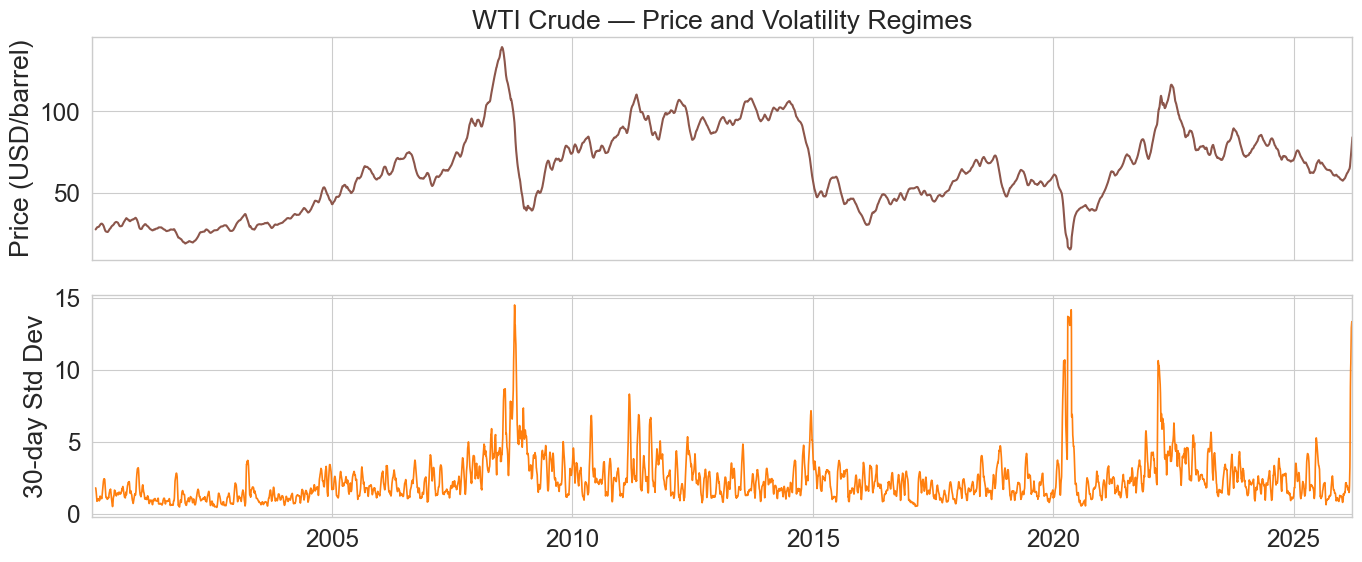

In [ ]:
rolling_std = wti.rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

wti.rolling(30).mean().plot(ax=axes[0], color="tab:brown", linewidth=1.5)
axes[0].set_ylabel("Price (USD/barrel)")
axes[0].set_title("WTI Crude — Price and Volatility Regimes")

#std deviation of the rolling window
rolling_std.plot(ax=axes[1], color="tab:orange", linewidth=1.2)
axes[1].set_ylabel("30-day Std Dev")
axes[1].set_xlabel("")

fig.tight_layout()
fig.savefig(DIAG / "wti_volatility_regimes.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Price Distribution

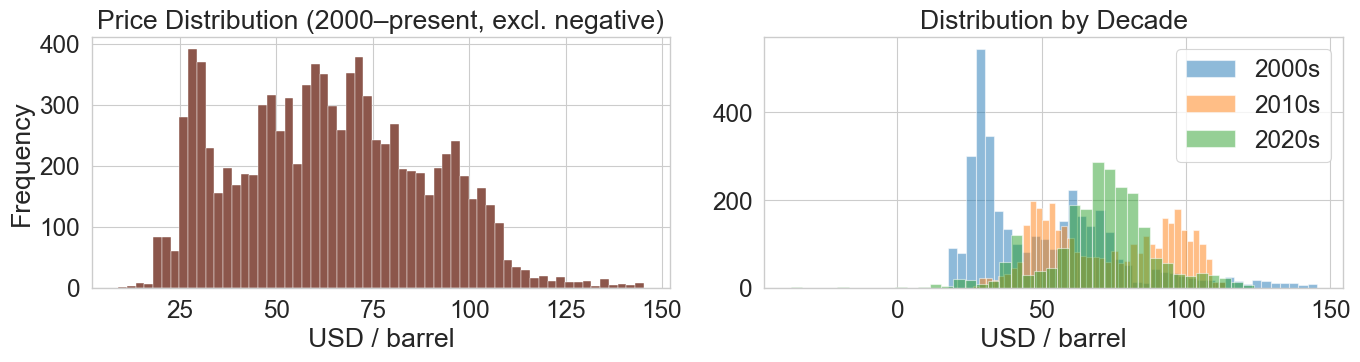

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Drop negative values for histogram display (April 2020 logistics anomaly)
wti_pos = wti[wti > 0].dropna()

axes[0].hist(wti_pos, bins=60, color="tab:brown", edgecolor="white", linewidth=0.3)
axes[0].set_title("Price Distribution (2000–present, excl. negative)")
axes[0].set_xlabel("USD / barrel")
axes[0].set_ylabel("Frequency")

wti_2000s = wti["2000":"2009"].dropna()
wti_2010s = wti["2010":"2019"].dropna()
wti_2020s = wti["2020":].dropna()

axes[1].hist(wti_2000s, bins=40, alpha=0.5, label="2000s", color="tab:blue")
axes[1].hist(wti_2010s, bins=40, alpha=0.5, label="2010s", color="tab:orange")
axes[1].hist(wti_2020s, bins=40, alpha=0.5, label="2020s", color="tab:green")
axes[1].set_title("Distribution by Decade")
axes[1].set_xlabel("USD / barrel")
axes[1].legend()

fig.tight_layout()
fig.savefig(DIAG / "wti_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

## 6. Observations

### Price regimes visible in the data

- **2000–2008:** Structural bull run — global demand growth (China industrialisation), Iraq war supply disruptions, and limited OPEC spare capacity drove WTI from ~$25 to a peak of ~$147/barrel in July 2008
- **2008–2009:** GFC collapse — demand destruction was violent and fast. WTI fell from $147 to ~$35 in six months
- **2010–2014:** Recovery and plateau — $80–110 range, supported by OPEC discipline and recovering global demand
- **2014–2016:** OPEC price war — Saudi Arabia chose to defend market share over price as US shale grew to ~9 Mb/d. WTI fell from ~$100 to ~$26 by Feb 2016
- **2017–2019:** Recovery to $50–65 range — OPEC+ (adding Russia) formed and managed supply
- **April 20, 2020 — Negative WTI:** Front-month futures settled at **−$37.63/barrel**. COVID collapsed global demand and Cushing storage was physically full. A pure logistics event, not an economic one — lasted one day
- **2021–2022:** V-shaped recovery into Ukraine spike — demand recovered faster than supply; WTI hit ~$130 in March 2022
- **2023–present:** Gradual drift lower — OPEC+ managing production, US shale growing, demand softening

---

### Why WTI is in a gas demand model

WTI is included as a **supply-side signal**, not a demand signal. The mechanism:

1. **Associated gas:** In oil basins (Permian, Eagle Ford), gas is produced as a byproduct of oil drilling. High WTI → more oil wells drilled → more associated gas → downward pressure on Henry Hub
2. **Lagged drilling response:** A $20 move in WTI changes active rig count within 3–6 months, which changes associated gas production within 6–12 months. WTI is a **leading indicator** of gas supply, not a coincident one
3. **Permian flaring:** When gas prices are low and oil prices are high, Permian operators flare associated gas rather than pipeline it. Supply destruction driven entirely by oil economics

**In the feature matrix:** WTI should enter as a lagged regressor (3–6 month lag), not contemporaneous.

---

### WTI vs Henry Hub — when the correlation holds and when it breaks

| Scenario | WTI | HH direction | Mechanism |
|---|---|---|---|
| High oil → more drilling | ↑ | ↓ (eventually) | More associated gas supply |
| Geopolitical supply shock | ↑ | ↑ | Both commodities impacted |
| Demand shock (recession) | ↓ | ↓ | Both hit by demand destruction |
| Cold winter | Flat | ↑ | Gas-specific, WTI unaffected |
| LNG export surge | Flat | ↑ | Gas-specific structural demand |

The correlation is **positive in demand-shock regimes** and **negative in supply-response regimes**. A linear model using contemporaneous WTI will be confused by this sign-switching.

---

### WTI-specific market structure

- **Delivery point:** Cushing, Oklahoma — largest crude storage hub in the US. WTI is landlocked; Brent (North Sea) is waterborne and trades at a premium post-shale
- **WTI vs Brent spread:** Pre-2010, WTI at premium to Brent. Post-shale, inverted as Cushing filled with shale crude. Normalised after US crude export ban lifted in 2015
- **OPEC+ meetings** are key event risk — production cut/increase announcements move WTI 3–5% immediately